# Ejercicio de programación Regresión Lineal Multiple

LAB2

Estudiante: Chelsea M. Espinoza Cava

Carrera: Ing. de Sistemas

In [157]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline
import pandas as pd
from sklearn.impute import KNNImputer

In [158]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Regresión lineal con multiples variables

Se utiliza un modelo de regresión lineal multivariable para predecir el nivel de glucosa en sangre (glucose_apache) utilizando variables fisiológicas del paciente como edad, índice de masa corporal, altura, peso, temperatura corporal y frecuencia cardíaca.

<a id="section4"></a>
### Normalización de caracteristicas

Las variables del dataset tienen diferentes magnitudes.

Para eso aplicamos normalización, con el objetivo de que todas las variables tengan escalas similares y el algoritmo de descenso por gradiente pueda converger más rápidamente.

In [159]:
# Cargar datos
data = pd.read_csv('/content/gdrive/MyDrive/IA26/DATA/TrainingWiDS2021.csv')

# Selección de variables
cols = ['age','bmi','height','weight','temp_apache','heart_rate_apache']

X = data[cols].values
y = data['glucose_apache'].values

# número de datos
m = y.size
print("Número de datos:", m)

# imprimir encabezados
print('{:>8s}{:>8s}{:>10s}{:>10s}{:>12s}{:>12s}{:>12s}'.format(
    'age','bmi','height','weight','temp','heart_rate','glucose'))

print('-'*100)

# imprimir primeras filas
for i in range(10):
    print('{:8.2f}{:8.2f}{:10.2f}{:10.2f}{:12.2f}{:12.2f}{:12.2f}'.format(
        X[i,0], X[i,1], X[i,2], X[i,3], X[i,4], X[i,5], y[i]))

Número de datos: 130157
     age     bmi    height    weight        temp  heart_rate     glucose
----------------------------------------------------------------------------------------------------
   68.00   22.73    180.30     73.90       39.30      118.00      168.00
   77.00   27.42    160.00     70.20       35.10      120.00      145.00
   25.00   31.95    172.70     95.30       36.70      102.00         nan
   81.00   22.64    165.10     61.70       34.80      114.00      185.00
   19.00     nan    188.00       nan       36.70       60.00         nan
   67.00   27.56    190.50    100.00       36.60      113.00      156.00
   59.00   57.45    165.10    156.60       35.00      133.00      197.00
   70.00     nan    165.00       nan       36.60      120.00      164.00
   45.00     nan    170.20       nan       36.90       82.00      380.00
   50.00   25.71    175.30     79.00       36.30       94.00      134.00


Imputacion basada en otras variables lo que usaremos sera K-Nearest Neighbors (KNN Imputation): el algoritmo busca filas parecidas y usa sus valores para estimar el NaN. No usa solo media o mediana global.

In [160]:
# columnas que estás usando
cols = ['age','bmi','height','weight','temp_apache','heart_rate_apache','glucose_apache']

df = data[cols].copy()

# imputador KNN
imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=cols)

# volver a separar X y y
X = df_imputed[['age','bmi','height','weight','temp_apache','heart_rate_apache']].values
y = df_imputed['glucose_apache'].values

In [161]:
print(df_imputed.head(10))

    age        bmi  height  weight  temp_apache  heart_rate_apache  \
0  68.0  22.732803   180.3   73.90         39.3              118.0   
1  77.0  27.421875   160.0   70.20         35.1              120.0   
2  25.0  31.952749   172.7   95.30         36.7              102.0   
3  81.0  22.635548   165.1   61.70         34.8              114.0   
4  19.0  22.849706   188.0   80.64         36.7               60.0   
5  67.0  27.555611   190.5  100.00         36.6              113.0   
6  59.0  57.451002   165.1  156.60         35.0              133.0   
7  70.0  23.667099   165.0   64.38         36.6              120.0   
8  45.0  26.659487   170.2   78.00         36.9               82.0   
9  50.0  25.707702   175.3   79.00         36.3               94.0   

   glucose_apache  
0           168.0  
1           145.0  
2           105.4  
3           185.0  
4            96.0  
5           156.0  
6           197.0  
7           164.0  
8           380.0  
9           134.0  


In [162]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [163]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 68.          22.73280282 180.3         73.9         39.3
  118.        ]
 [ 77.          27.421875   160.          70.2         35.1
  120.        ]
 [ 25.          31.95274882 172.7         95.3         36.7
  102.        ]
 ...
 [ 73.          32.26537065 177.8        102.          32.9
  104.        ]
 [ 81.          24.40857925 185.4         83.9         35.5
   83.        ]
 [ 35.          30.13235818 182.9        100.8         37.1
   97.        ]]
Media calculada: [ 61.82090395  29.06234972 169.56830673  83.61530964  36.42392278
  99.83340316]
Desviación estandar calculada: [16.62883856  8.17448248 10.77225819 24.7373717   0.8390162  30.7351948 ]
[[ 0.37158915 -0.77430552  0.99623432 -0.39273815  3.42791618  0.59106822]
 [ 0.91281757 -0.20068239 -0.88823593 -0.54230942 -1.57794661  0.6561402 ]
 [-2.21427996  0.35358802  0.29071836  0.47234971  0.32904874  0.07049237]
 ...
 [ 0.67227161  0.39183165  0.7641567   0.74319498 -4.20006521  0.13556435]
 [ 1.15336354 -0.5693046   1.4

In [164]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
m = X_norm.shape[0]
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

<a id="section5"></a>
### Descenso por el gradiente



$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$



In [166]:
#funcion de costo
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [167]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0]

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [159.59342463   2.63960372   4.55847443  -1.75315012   5.30219639
  -6.93150339  10.18807736]


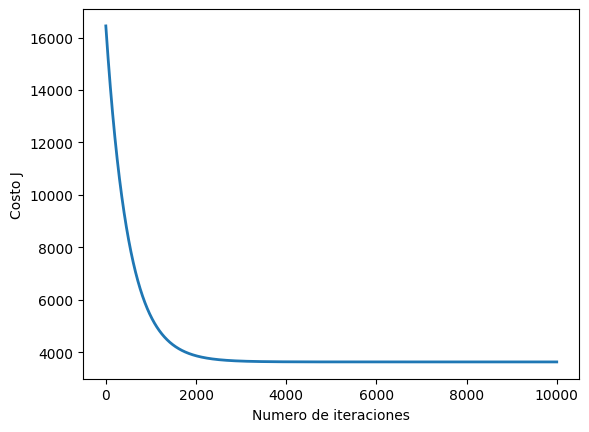

In [168]:
# Entrenar el modelo
alpha = 0.001
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))


In [169]:
# ejemplo de paciente
X_array = np.array([1, 60, 27, 170, 75, 37, 90], dtype=float)

# normalizar
X_array[1:] = (X_array[1:] - mu) / sigma

pred_grad = np.dot(X_array, theta)

print("Glucosa predicha:", pred_grad)

Glucosa predicha: 148.21864927876888


<a id="section7"></a>
### Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Es un metodo alternativo para calcular los parametros de un modelo a diferencia del desenso po rle gradiente este permite obtener la solucion exacta mediante una sola operacion matricial.
No require normalizar y no necesita iteraciones para converger, se debe recargar los datos originales y se agrega una columna de unos a la matriz x la cual correcponde al termino de interseccion
($\theta_0$).

In [170]:
# Cargar datos ya limpios de nan
X2 = df_imputed[['age','bmi','height','weight','temp_apache','heart_rate_apache']].values
y = df_imputed['glucose_apache'].values

m = y.size
print('Número de datos:', m)

# agregar columna de unos
X2 = np.concatenate([np.ones((m,1)), X2], axis=1)

Número de datos: 130157


In [171]:
def normalEqn(X, y):

    theta2 = np.zeros(X.shape[1])

    theta2 = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta2

In [172]:
# Calcula los parametros con la ecuación de la normal
theta2 = normalEqn(X2, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta2)));

# Predicción
# ejemplo de paciente
# ejemplo de paciente
X_array2 = np.array([1, 60, 27, 170, 75, 37, 90], dtype=float)

pred_normal = np.dot(X_array2, theta2)

print("Glucosa predicha (ecuación normal):", pred_normal)

Theta calculado a partir de la ecuación de la normal: [ 4.45300307e+02  1.58330144e-01  1.13267066e-02 -3.65564163e-01
  4.10944406e-01 -8.27187194e+00  3.31591534e-01]
Glucosa predicha (ecuación normal): 147.56483553705453


REGRESION POLINOMICA

In [173]:
X3 = df_imputed[['age','bmi','height','weight','temp_apache','heart_rate_apache']].values
y = df_imputed['glucose_apache'].values

m = y.size

In [174]:
# crear características polinómicas (cuadrado)
X_poly = np.concatenate((X3, X3**2), axis=1)

In [175]:
#normalizamos
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

In [176]:
#columna de 1
X_poly = np.concatenate([np.ones((m,1)), X_poly_norm], axis=1)

In [177]:
#entrenamos el modelo
alpha = 0.005
num_iters = 10000

theta3 = np.zeros(X_poly.shape[1])

theta3, J_history_poly = gradientDescentMulti(X_poly, y, theta3, alpha, num_iters)

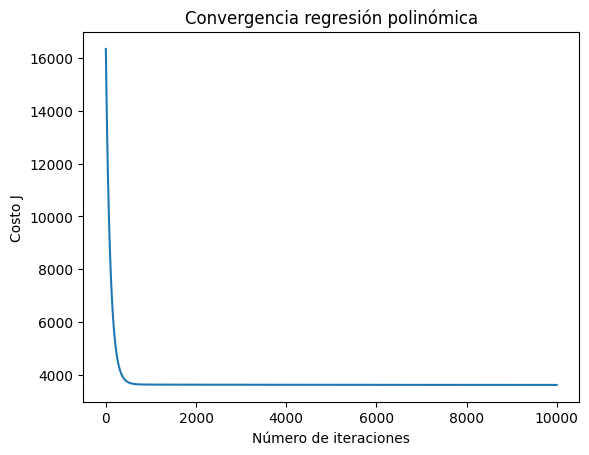

In [178]:
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title("Convergencia regresión polinómica")
pyplot.show()

In [179]:
# ejemplo de paciente
X_test = np.array([60,27,170,75,37,90])

# crear variables polinómicas
X_test_poly = np.concatenate((X_test, X_test**2))

# normalizar
X_test_poly = (X_test_poly - mu_poly) / sigma_poly

# agregar sesgo
X_test_poly = np.concatenate(([1], X_test_poly))

pred_poly = np.dot(X_test_poly, theta3)

print("Glucosa predicha (regresión polinómica):", pred_poly)

Glucosa predicha (regresión polinómica): 149.81979781237965


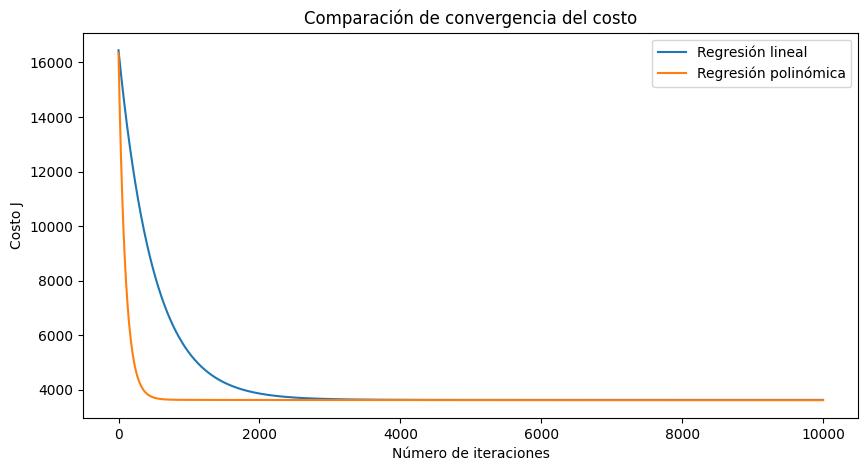

In [180]:
pyplot.figure(figsize=(10,5))

# regresión lineal
pyplot.plot(np.arange(len(J_history)), J_history, label="Regresión lineal")

# regresión polinómica
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, label="Regresión polinómica")

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Comparación de convergencia del costo")
pyplot.legend()

pyplot.show()

In [181]:
print("Comparación de modelos\n")
print("Descenso por gradiente:", pred_grad)
print("Ecuación normal:", pred_normal)
print("Regresión polinómica:", pred_poly)

Comparación de modelos

Descenso por gradiente: 148.21864927876888
Ecuación normal: 147.56483553705453
Regresión polinómica: 149.81979781237965


In [184]:
pred_grad_all = np.dot(X, theta)
pred_normal_all = np.dot(X2, theta2)
pred_poly_all = np.dot(X_poly, theta3)

In [185]:
tabla = pd.DataFrame({
    "Glucosa_real": y[:20],
    "Gradiente": pred_grad_all[:20],
    "Ecuacion_normal": pred_normal_all[:20],
    "Polinomica": pred_poly_all[:20]
})

print(tabla)

    Glucosa_real   Gradiente  Ecuacion_normal  Polinomica
0          168.0  135.476934       134.825051  135.695439
1          145.0  177.392225       177.608638  177.504945
2          105.4  155.792622       155.895187  153.157836
3          185.0  173.195761       173.322353  170.123068
4           96.0  130.209551       129.297678  122.583514
5          156.0  162.590426       162.394339  163.047868
6          197.0  214.104918       213.877923  207.578746
7          164.0  159.733842       159.830472  160.170855
8          380.0  144.432498       144.520202  145.990714
9          134.0  153.014381       152.789861  154.187060
10         109.4  157.037274       157.342136  158.296336
11         123.0  158.798333       158.998869  157.658866
12          98.0  153.761620       151.156433  153.831910
13         119.0  162.817379       162.679132  164.720527
14         120.0  174.476805       174.804185  173.715176
15          90.0  153.479652       155.338832  154.011632
16          88

Se observa que las predicciones no coinciden exactamente con los valores reales de glucosa. Esto se debe a que la regresión lineal intenta aproximar la relación entre las variables utilizando una función lineal simple, mientras que en la práctica los valores fisiológicos dependen de muchos factores adicionales no incluidos en el modelo.